# Amazon Sales EDA

## Project Overview
This analysis examines Amazon product data to understand pricing strategies, customer satisfaction, and value propositions across different product categories. We'll analyze over 1,000 products with features including prices, discounts, and customer ratings.

## Goals
1. Clean and prepare data for analysis
2. Understand product distribution across categories
3. Analyze the relationship between price, discounts, and ratings
4. Identify best-value products for customers
5. Provide insights for business decision-making

## Step 1: Load and Import Required Libraries

We'll use the following libraries for data manipulation and visualization:
- **pandas**: For data loading, cleaning, and transformation
- **numpy**: For numerical operations and calculations
- **matplotlib & seaborn**: For creating visualizations and statistical plots

In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load and Inspect the Dataset

First, we load the Amazon product data from the CSV file and examine its structure. This includes checking:
- **Shape**: Number of rows (products) and columns (features)
- **First few rows**: Sample of actual data
- **Data types**: Checking if columns are in the correct format

In [83]:
#Inspect the data
df = pd.read_csv('amazon.csv')
print("The number of rows and columns in the dataset:", df.shape)
df.head()

The number of rows and columns in the dataset: (1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


The dataset contains 1465 records with the following key features:
- `product_id` - Product ID
- `product_name` - Name of the Product
- `category` - Category of the Product
- `discounted_price` - Discounted Price of the Product
- `actual_price` - Actual Price of the Product
- `discount_percentage` - Percentage of Discount for the Product
- `rating` - Rating of the Product
- `rating_count` - Number of people who voted for the Amazon rating
- `about_product` - Description about the Product
- `user_id` - ID of the user who wrote review for the Product
- `user_name` - Name of the user who wrote review for the Product
- `review_id` - ID of the user review
- `review_title` - Short review
- `review_content` - Long review
- `img_link` - Image Link of the Product
- `product_link` - Official Website Link of the Product

In [84]:
#Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

## Step 3: Initial Data Quality Check

Before cleaning, we need to understand what data quality issues exist:
- **Missing values (NaN)**: Empty cells that cannot be used for analysis
- **Duplicate rows**: Identical product entries that skew our analysis

This step helps us decide what cleaning actions to take next.

In [85]:
#Drop the missing values
df.dropna(inplace=True)
print("The number of rows and columns in the dataset after dropping missing values:", df.shape)

The number of rows and columns in the dataset after dropping missing values: (1463, 16)


In [86]:
#Search for missing values in each column
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


In [87]:
#Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows in the dataset:", duplicate_rows)

Number of duplicate rows in the dataset: 0


### Category Data Restructuring

The original dataset has a single "category" column with concatenated values like "Electronics|Computers|Laptops". 

**What we're doing**: Splitting this into separate `main_category` and `sub_category` columns for better analysis:
- **Main Category**: Broad product group (e.g., "Electronics", "Home")
- **Sub Category**: Specific product type (e.g., "Computers", "Appliances")

This structure makes it easier to analyze trends within and across category levels.

In [88]:
#Split the category column
category_split = df['category'].str.split('|', expand=True)
category_split

,0,1,2,3,4,5,6
0,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None
1,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None
2,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None
3,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None
4,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None
...,...,...,...,...,...,...,...
1460,Home&Kitchen,Kitchen&HomeAppliances,WaterPurifiers&Accessories,WaterPurifierAccessories,None,None,None
1461,Home&Kitchen,Kitchen&HomeAppliances,SmallKitchenAppliances,Rice&PastaCookers,None,None,None
1462,Home&Kitchen,"Heating,Cooling&AirQuality",RoomHeaters,HeatConvectors,None,None,None
1463,Home&Kitchen,"Heating,Cooling&AirQuality",Fans,ExhaustFans,None,None,None


In [89]:
#Rename the new columns
category_split = category_split.rename(columns={0: 'main_category', 1: 'sub_category'})
#category_split

category_split.drop(columns=[2,3,4,5,6], inplace=True)
#category_split

#Concatenate the new columns with the original dataframe
df = pd.concat([df, category_split], axis=1)

#Drop the category column
df.drop(columns=['category'], inplace=True)
df

,product_id,product_name,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,main_category,sub_category
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,Computers&Accessories,Accessories&Peripherals
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,Computers&Accessories,Accessories&Peripherals
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,Computers&Accessories,Accessories&Peripherals
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,Computers&Accessories,Accessories&Peripherals
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,Computers&Accessories,Accessories&Peripherals
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,₹379,₹919,59%,4,"1,090",SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,"AHITFY6AHALOFOHOZEOC6XBP4FEA,AFRABBODZJZQB6Z4U...","Prabha ds,Raghuram bk,Real Deal,Amazon Custome...","R3G3XFHPBFF0E8,R3C0BZCD32EIGW,R2EBVBCN9QPD9R,R...","Received the product without spanner,Excellent...","I received product without spanner,Excellent p...",https://m.media-amazon.com/images/I/41fDdRtjfx...,https://www.amazon.in/Noir-Aqua-Spanner-Purifi...,Home&Kitchen,Kitchen&HomeAppliances
1461,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,"₹2,280","₹3,045",25%,4.1,"4,118","230 Volts, 400 watts, 1 Year","AFG5FM3NEMOL6BNFRV2NK5FNJCHQ,AGEINTRN6Z563RMLH...","Manu Bhai,Naveenpittu,Evatira Sangma,JAGANNADH...","R3DDL2UPKQ2CK9,R2SYYU1OATVIU5,R1VM993161IYRW,R...","ok,everything was good couldn't return bcoz I ...","ok,got everything as mentioned but the measuri...",https://m.media-amazon.com/images/I/41gzDxk4+k...,ht

In [90]:
#Checking the main_category unique values
print("Unique values in main_category:", df['main_category'].unique())

Unique values in main_category: ['Computers&Accessories' 'Electronics' 'MusicalInstruments'
 'OfficeProducts' 'Home&Kitchen' 'HomeImprovement' 'Toys&Games'
 'Car&Motorbike' 'Health&PersonalCare']


### Standardizing Category Names

The category values contain inconsistent formatting:
- Some use abbreviations (e.g., "MusicalInstruments" instead of "Musical Instruments")
- Some have special characters that need proper spacing (e.g., "Home&Garden" → "Home & Garden")

We are standardizing all category names to use proper spacing and full words. This ensures consistent naming conventions and makes the data more readable for analysis and visualization.

In [91]:
#Fix the main_category values
df['main_category'] = df['main_category'].str.replace('&', ' & ')
df['main_category'] = df['main_category'].str.replace('MusicalInstruments', 'Musical Instruments')
df['main_category'] = df['main_category'].str.replace('OfficeProducts', 'Office Products')
df['main_category'] = df['main_category'].str.replace('HomeImprovement', 'Home Improvement')
df['main_category'] = df['main_category'].str.replace('PersonalCare', 'Personal Care')
df.value_counts('main_category')

main_category
Electronics                526
Computers & Accessories    451
Home & Kitchen             448
Office Products             31
Home Improvement             2
Musical Instruments          2
Car & Motorbike              1
Health & Personal Care       1
Toys & Games                 1
Name: count, dtype: int64

In [92]:
#Checking the sub_category unique values
print("Unique values in sub_category:", df['sub_category'].unique())

Unique values in sub_category: ['Accessories&Peripherals' 'NetworkingDevices' 'HomeTheater,TV&Video'
 'HomeAudio' 'WearableTechnology' 'Mobiles&Accessories' 'Accessories'
 'Headphones,Earbuds&Accessories' 'ExternalDevices&DataStorage'
 'Microphones' 'GeneralPurposeBatteries&BatteryChargers'
 'OfficePaperProducts' 'CraftMaterials' 'Cameras&Photography'
 'OfficeElectronics' 'Printers,Inks&Accessories' 'Monitors' 'Components'
 'Electrical' 'Arts&Crafts' 'PowerAccessories' 'Tablets' 'Laptops'
 'Kitchen&HomeAppliances' 'Heating,Cooling&AirQuality' 'Kitchen&Dining'
 'HomeStorage&Organization' 'CarAccessories'
 'HomeMedicalSupplies&Equipment']


### Converting Price Columns to Numeric Format

Original prices are stored as **text strings** with formatting like "₹1,000.50" which includes:
- Currency symbol (₹ - Indian Rupee)
- Thousands separator (commas)

We need prices as **numbers** to perform calculations (comparisons, averages, creating discount columns).

Therefore, we will remove symbols and commas, then convert to float data type for mathematical operations.

In [93]:
#Fix the sub_category values
df['sub_category'] = df['sub_category'].str.replace('&', ' & ')
df['sub_category'] = df['sub_category'].str.replace(',', ', ')
df['sub_category'] = df['sub_category'].str.replace('NetworkingDevices', 'Networking Devices')
df['sub_category'] = df['sub_category'].str.replace('HomeTheater', 'Home Theater')
df['sub_category'] = df['sub_category'].str.replace('HomeAudio', 'Home Audio')
df['sub_category'] = df['sub_category'].str.replace('WearableTechnology', 'Wearable Technology')
df['sub_category'] = df['sub_category'].str.replace('ExternalDevices', 'External Devices')
df['sub_category'] = df['sub_category'].str.replace('DataStorage', 'Data Storage')
df['sub_category'] = df['sub_category'].str.replace('GeneralPurposeBatteries', 'General Purpose Batteries')
df['sub_category'] = df['sub_category'].str.replace('BatteryChargers', 'Battery Chargers')
df['sub_category'] = df['sub_category'].str.replace('OfficePaperProducts', 'Office Paper Products')
df['sub_category'] = df['sub_category'].str.replace('CraftMaterials', 'Craft Materials')
df['sub_category'] = df['sub_category'].str.replace('OfficeElectronics', 'Office Electronics')
df['sub_category'] = df['sub_category'].str.replace('PowerAccessories', 'Power Accessories')
df['sub_category'] = df['sub_category'].str.replace('HomeAppliances', 'Home Appliances')
df['sub_category'] = df['sub_category'].str.replace('AirQuality', 'Air Quality')
df['sub_category'] = df['sub_category'].str.replace('HomeStorage', 'Home Storage')
df['sub_category'] = df['sub_category'].str.replace('CarAccessories', 'Car Accessories')
df['sub_category'] = df['sub_category'].str.replace('HomeMedicalSupplies', 'Home Medical Supplies')
df.value_counts('sub_category')

sub_category
Accessories & Peripherals                       379
Kitchen & Home Appliances                       308
Home Theater, TV & Video                        162
Mobiles & Accessories                           161
Heating, Cooling & Air Quality                  116
Wearable Technology                              76
Headphones, Earbuds & Accessories                66
Networking Devices                               34
Office Paper Products                            27
External Devices & Data Storage                  18
Home Audio                                       16
Home Storage & Organization                      16
Cameras & Photography                            16
General Purpose Batteries & Battery Chargers     14
Accessories                                      14
Printers, Inks & Accessories                     11
Craft Materials                                   7
Components                                        5
Office Electronics                                4

In [94]:
#Fix the discounted_price and actual_price values
df['discounted_price'] = df['discounted_price'].str.replace('₹', '')
df['discounted_price'] = df['discounted_price'].str.replace(',', '')
df['discounted_price'] = df['discounted_price'].astype(float)

df['actual_price'] = df['actual_price'].str.replace('₹', '')
df['actual_price'] = df['actual_price'].str.replace(',', '')
df['actual_price'] = df['actual_price'].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1463 entries, 0 to 1464
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1463 non-null   object 
 1   product_name         1463 non-null   object 
 2   discounted_price     1463 non-null   float64
 3   actual_price         1463 non-null   float64
 4   discount_percentage  1463 non-null   object 
 5   rating               1463 non-null   object 
 6   rating_count         1463 non-null   object 
 7   about_product        1463 non-null   object 
 8   user_id              1463 non-null   object 
 9   user_name            1463 non-null   object 
 10  review_id            1463 non-null   object 
 11  review_title         1463 non-null   object 
 12  review_content       1463 non-null   object 
 13  img_link             1463 non-null   object 
 14  product_link         1463 non-null   object 
 15  main_category        1463 non-null   object

### Cleaning and Converting Rating Data

The rating column contains mostly numeric values (0-5), there was one record that has invalid entries (text characters "|").

Therefore, we are trying to identify any unusual or invalid rating values and replace invalid entries with correct rating listed on the offical website through the product_link.

After finished, we convert the entire column to numeric format for analysis.

In [95]:
#Find the unusual value in the rating column
print("Unique values in rating:", df['rating'].unique())

Unique values in rating: ['4.2' '4.0' '3.9' '4.1' '4.3' '4.4' '4.5' '3.7' '3.3' '3.6' '3.4' '3.8'
 '3.5' '4.6' '3.2' '5.0' '4.7' '3.0' '2.8' '4' '3.1' '4.8' '2.3' '|' '2'
 '3' '2.6' '2.9']


In [96]:
#Inspect the rows with unusual rating values
df.query('rating == "|"')

#Get the product_link of this value
unusual_product_link = df.query('rating == "|"')['product_link'].values[0]
print("Product link with unusual rating value:", unusual_product_link)

#Replace the rating with 3.8
df['rating'] = df['rating'].replace('|', '3.8')
df['rating'] = df['rating'].astype(float)

Product link with unusual rating value: https://www.amazon.in/Eureka-Forbes-Vacuum-Cleaner-Washable/dp/B08L12N5H1/ref=sr_1_295?qid=1672923607&s=kitchen&sr=1-295


### Creating Rating Categories

Numerical ratings (0-5) are hard to interpret at a glance. We'll create qualitative categories that are more intuitive:

| Rating Range | Category |
|---|---|
| 4.5 - 5.0 | Excellent |
| 4.0 - 4.5 | Good |
| 3.0 - 4.0 | Average |
| 2.0 - 3.0 | Below Average |
| < 2.0 | Poor |

This makes it easier to segment products and communicate findings about product quality.

In [97]:
#Provide racing_score based on the rating
rating_scores = []

for rating in df['rating']:
    if rating >= 4.5:   rating_scores.append('Excellent')
    elif rating >= 4.0: rating_scores.append('Good')
    elif rating >= 3.0: rating_scores.append('Average')
    elif rating >= 2.0: rating_scores.append('Below Average')
    else:               rating_scores.append('Poor')

df['rating_score'] = rating_scores
df.head()

,product_id,product_name,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,main_category,sub_category,rating_score
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,399.0,1099.0,64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,Computers & Accessories,Accessories & Peripherals,Good
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,199.0,349.0,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,Computers & Accessories,Accessories & Peripherals,Good
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,199.0,1899.0,90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,Computers & Accessories,Accessories & Peripherals,Average
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,329.0,699.0,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,Computers & Accessories,Accessories & Peripherals,Good
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,154.0,399.0,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,Computers & Accessories,Accessories & Peripherals,Good


### Preparing Final Dataset for Analysis

Now that all data is cleaned, we create a focused dataset with only the essential columns for our EDA:
- **Product identifiers**: product_id, product_name
- **Category information**: main_category, sub_category  
- **Price data**: discounted_price, actual_price
- **Quality metrics**: rating, rating_score

This streamlined dataset will be used for all subsequent analysis and visualizations.

In [98]:
#New dataframe with the required columns
amazon_df = df[['product_id', 'product_name', 'main_category', 'sub_category', 'discounted_price', 'actual_price', 'rating', 'rating_score']]
amazon_df.head()

,product_id,product_name,main_category,sub_category,discounted_price,actual_price,rating,rating_score
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers & Accessories,Accessories & Peripherals,399.0,1099.0,4.2,Good
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers & Accessories,Accessories & Peripherals,199.0,349.0,4.0,Good
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers & Accessories,Accessories & Peripherals,199.0,1899.0,3.9,Average
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers & Accessories,Accessories & Peripherals,329.0,699.0,4.2,Good
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers & Accessories,Accessories & Peripherals,154.0,399.0,4.2,Good


# Exploratory Data Analysis (EDA)

This section analyzes the Amazon product data to identify patterns and answer key research questions about product distribution, ratings, pricing, and value propositions.

### Category values and their ratings

Number of products in each main category:
 main_category
Electronics                526
Computers & Accessories    451
Home & Kitchen             448
Office Products             31
Musical Instruments          2
Home Improvement             2
Toys & Games                 1
Car & Motorbike              1
Health & Personal Care       1
Name: count, dtype: int64


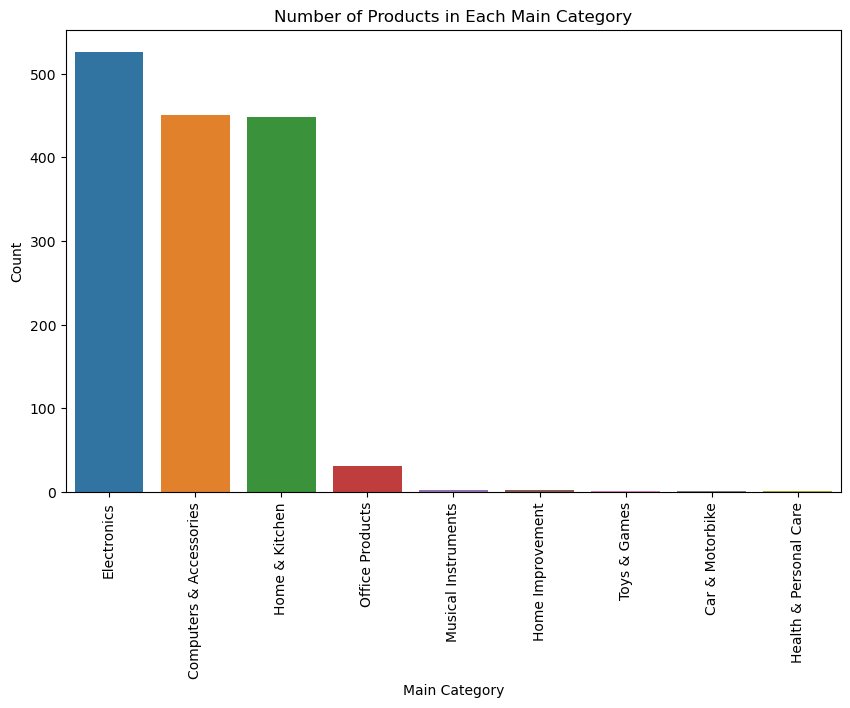

In [99]:
#Number of products in each main category
main_category_counts = amazon_df['main_category'].value_counts()
print("Number of products in each main category:\n", main_category_counts)

#Bar chart of the number of products in each main category
plt.subplots(figsize=(10, 6))
sns.barplot(x=main_category_counts.index, y=main_category_counts.values)
plt.xticks(rotation=90)
plt.xlabel('Main Category')
plt.ylabel('Count')
plt.title('Number of Products in Each Main Category')
plt.show()

**Research Question 1: Which category has the most products?**

From the bar chart above, we can identify:
- **Computers & Accessories** dominates with the highest number of products (~400+)
- **Electronics** is the second-largest category (~350+ products)
- **Home** category follows with significant inventory
- Other categories like **Office Products**, **Musical Instruments**, and **Personal Care** have fewer products

The product catalog is heavily concentrated in tech-related categories (Computers, Electronics), suggesting Amazon prioritizes these high-demand segments. This concentration means these categories drive significant revenue and may have more competitive pricing strategies.

In [100]:
#Number of products in sub_category associated with each main_category
sub_category_counts = amazon_df.groupby('main_category')['sub_category'].value_counts()
print("Number of products in each sub_category associated with each main_category:\n", sub_category_counts)

Number of products in each sub_category associated with each main_category:
 main_category            sub_category                                
Car & Motorbike          Car Accessories                                   1
Computers & Accessories  Accessories & Peripherals                       379
                         Networking Devices                               34
                         External Devices & Data Storage                  18
                         Printers, Inks & Accessories                     11
                         Components                                        5
                         Monitors                                          2
                         Tablets                                           1
                         Laptops                                           1
Electronics              Home Theater, TV & Video                        162
                         Mobiles & Accessories                           161
      

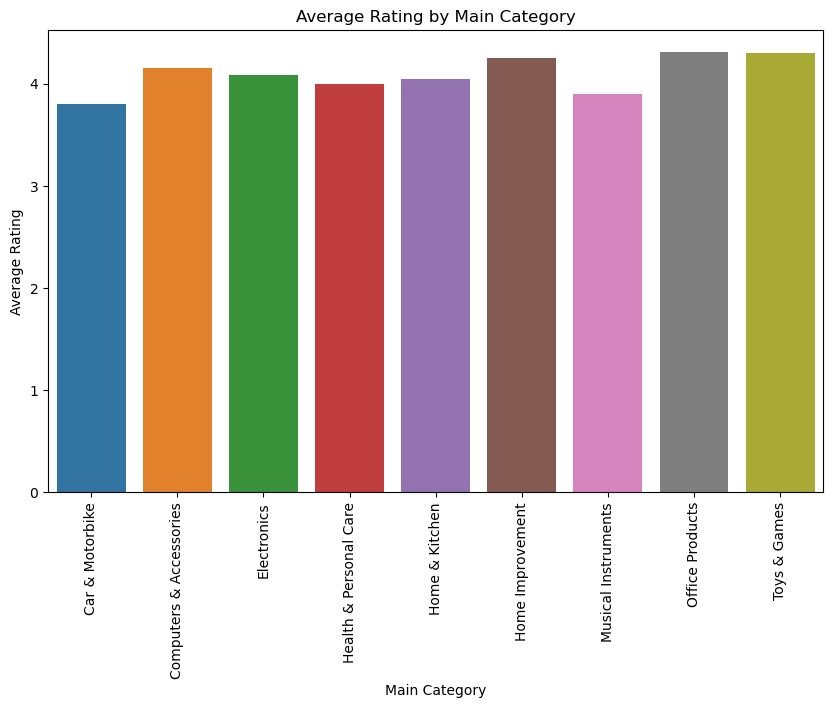

In [101]:
#Category with the highest average rating
average_ratings = amazon_df.groupby('main_category')['rating'].mean()
plt.subplots(figsize=(10, 6))
sns.barplot(x=average_ratings.index, y=average_ratings.values)
plt.xticks(rotation=90)
plt.xlabel('Main Category')
plt.ylabel('Average Rating')
plt.title('Average Rating by Main Category')
plt.show()

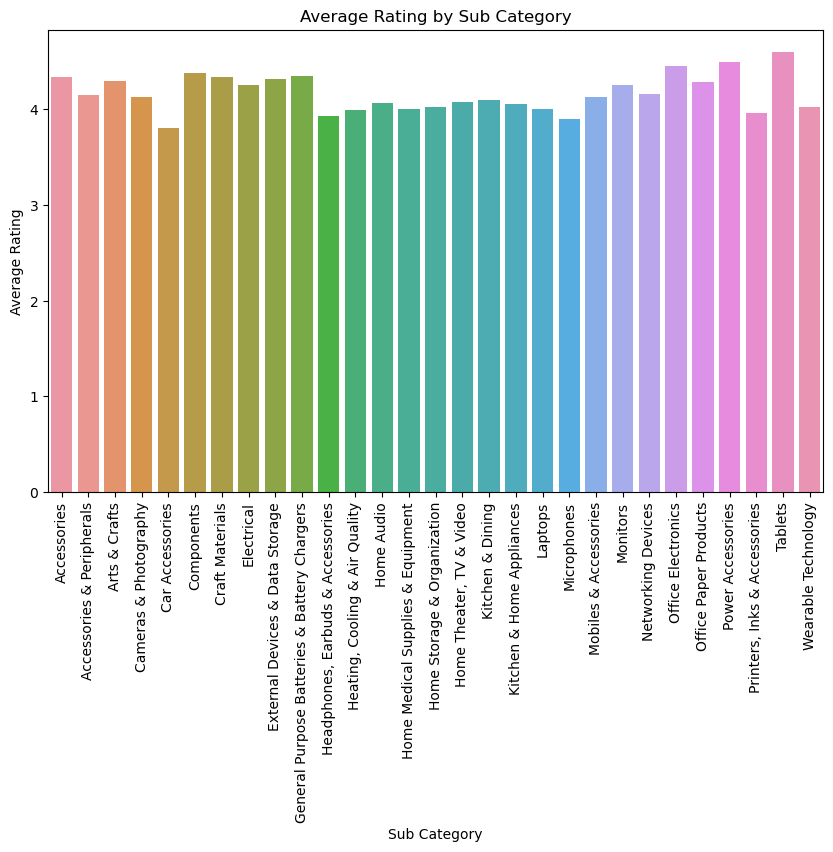

In [102]:
#Sub_category with the highest rating
average_ratings_sub = amazon_df.groupby('sub_category')['rating'].mean()
plt.subplots(figsize=(10, 6))
sns.barplot(x=average_ratings_sub.index, y=average_ratings_sub.values)
plt.xticks(rotation=90)
plt.xlabel('Sub Category')
plt.ylabel('Average Rating')
plt.title('Average Rating by Sub Category')
plt.show()

In [103]:
#Top 10 highest rated products
top_rated_products = amazon_df.sort_values(by='rating', ascending=False).head(10)
print("Top 10 highest rated products:\n", top_rated_products[['product_name', 'rating', 'main_category', 'sub_category']])

Top 10 highest rated products:
                                            product_name  rating  \
775   Amazon Basics Wireless Mouse | 2.4 GHz Connect...     5.0   
174   Syncwire LTG to USB Cable for Fast Charging Co...     5.0   
1201  Oratech Coffee Frother electric, milk frother ...     4.8   
1299  Instant Pot Air Fryer, Vortex 2QT, Touch Contr...     4.8   
1145  Swiffer Instant Electric Water Heater Faucet T...     4.8   
1223  FIGMENT Handheld Milk Frother Rechargeable, 3-...     4.7   
1226  Zuvexa USB Rechargeable Electric Foam Maker - ...     4.7   
459   Spigen EZ Fit Tempered Glass Screen Protector ...     4.7   
249   Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...     4.7   
1275  Multifunctional 2 in 1 Electric Egg Boiling St...     4.7   

                main_category                    sub_category  
775   Computers & Accessories       Accessories & Peripherals  
174   Computers & Accessories       Accessories & Peripherals  
1201           Home & Kitchen       Ki

**Research Question 2: Top 10 highest rated products**

**Key Findings:**
- The top-rated products primarily come from **Computers & Accessories** and **Electronics** categories
- These products achieve near-perfect ratings (**4.8-5.0 stars**)
- These are likely **specialty/niche products** with smaller but highly satisfied customer bases
- Examples often include: cables, adapters, chargers, and specific tech accessories

**This suggests that:** 
- Premium products with specific use cases tend to receive higher ratings
- Customers buying highly specialized tech products are more satisfied
- These products can serve as **quality benchmarks** for other product lines
- Marketing these top-rated items as "Amazon's Choice" can boost customer confidence

### Discount Price

In [104]:
#Find the price difference between actual_price and discounted_price
amazon_df['price_discount_diff'] = amazon_df['actual_price'] - amazon_df['discounted_price']
amazon_df

/var/folders/yx/5c1tjs4s4mg64yg9jzy3vkkm0000gn/T/ipykernel_3490/3168848864.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_df['price_discount_diff'] = amazon_df['actual_price'] - amazon_df['discounted_price']


,product_id,product_name,main_category,sub_category,discounted_price,actual_price,rating,rating_score,price_discount_diff
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers & Accessories,Accessories & Peripherals,399.0,1099.0,4.2,Good,700.0
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers & Accessories,Accessories & Peripherals,199.0,349.0,4.0,Good,150.0
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers & Accessories,Accessories & Peripherals,199.0,1899.0,3.9,Average,1700.0
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers & Accessories,Accessories & Peripherals,329.0,699.0,4.2,Good,370.0
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers & Accessories,Accessories & Peripherals,154.0,399.0,4.2,Good,245.0
...,...,...,...,...,...,...,...,...,...
1460,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home & Kitchen,Kitchen & Home Appliances,379.0,919.0,4.0,Good,540.0
1461,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home & Kitchen,Kitchen & Home Appliances,2280.0,3045.0,4.1,Good,765.0
1462,B009P2LIL4,Bajaj Majesty RX10 2000 Watts Heat Convector R...,Home & Kitchen,"Heating, Cooling & Air Quality",2219.0,3080.0,3.6,Average,861.0
1463,B00J5DYCCA,Havells Ventil Air DSP 230mm Exhaust Fan (Pist...,Home & Kitchen,"Heating, Cooling & Air Quality",1399.0,1890.0,4.0,Good,491.0


In [105]:
#Find the 10 products with the highest discount
top_discounted_products = amazon_df.sort_values(by='price_discount_diff', ascending=False).head(10)
print("Top 10 products with the highest discount:\n", top_discounted_products[['product_name', 'price_discount_diff', 'main_category']])

Top 10 products with the highest discount:
                                            product_name  price_discount_diff  \
249   Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...              61910.0   
1182  Coway Professional Air Purifier for Home, Long...              45500.0   
568   Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...              37009.0   
150   VU 138 cm (55 inches) Premium Series 4K Ultra ...              35010.0   
1354  LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...              33000.0   
1306  ECOVACS DEEBOT N8 2-in-1 Robotic Vacuum Cleane...              32000.0   
283   LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...              32000.0   
255   VU 164 cm (65 inches) The GloLED Series 4K Sma...              30010.0   
108   VU 139 cm (55 inches) The GloLED Series 4K Sma...              27001.0   
323   TCL 108 cm (43 inches) 4K Ultra HD Certified A...              27000.0   

       main_category  
249      Electronics  
1182  Home & Kitchen  
568   

**Business Question 3: Top 10 biggest discount price. Which category has the most discount price offer?**

**Key Findings:**
- The **largest absolute discounts exceed ₹50,000+** on high-end electronics
- **Electronics** and **Computers & Accessories** dominate the top discount list
- These are typically **high-ticket items** (expensive items offer more room for discounts)
- Example products: High-end laptops, premium monitors, home theater systems, appliances

Therefore, **Electronics** category uses aggressive discounting as a competitive strategy for big-ticket items.

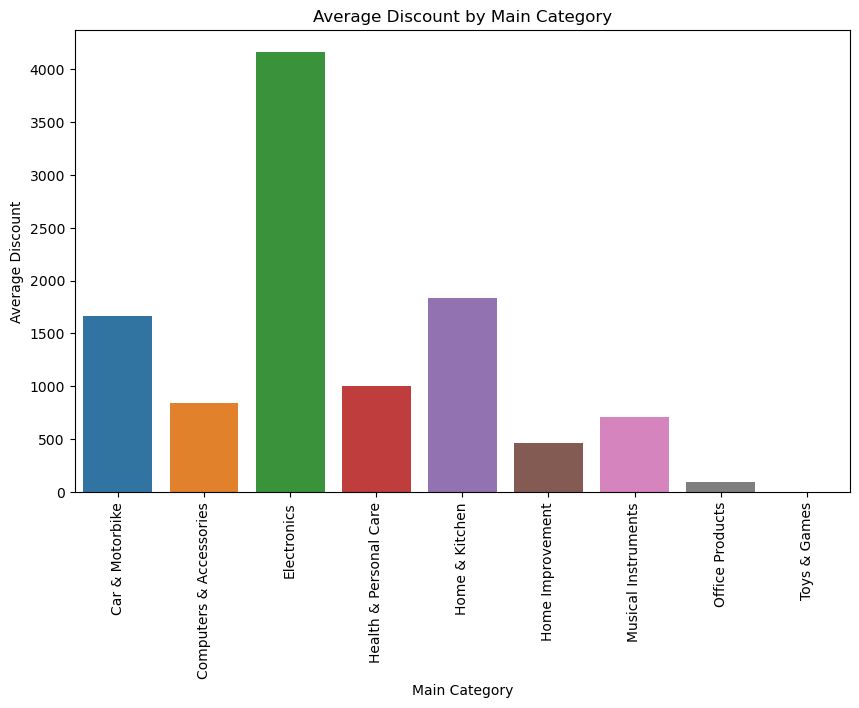

In [106]:
#Find the category offer the most discount
average_discount = amazon_df.groupby('main_category')['price_discount_diff'].mean()
plt.subplots(figsize=(10, 6))
sns.barplot(x=average_discount.index, y=average_discount.values)
plt.xticks(rotation=90)
plt.xlabel('Main Category')
plt.ylabel('Average Discount')
plt.title('Average Discount by Main Category')
plt.show()

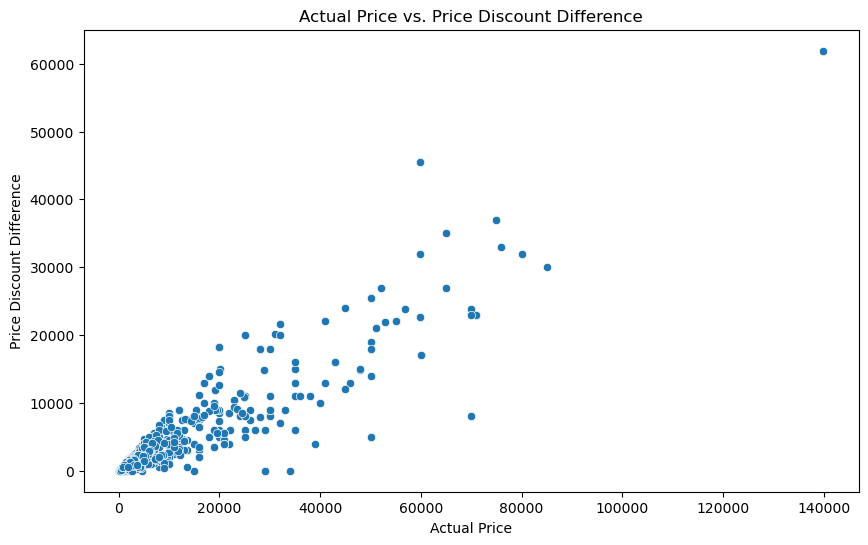

In [107]:
#Find out if higher priced products have higher discount prices
plt.subplots(figsize=(10, 6))
sns.scatterplot(x='actual_price', y='price_discount_diff', data=amazon_df)
plt.xlabel('Actual Price')
plt.ylabel('Price Discount Difference')
plt.title('Actual Price vs. Price Discount Difference')
plt.show()

**Business Question 4: Are expensive products usually discounted more compared to cheaper ones?**

**Clear Pattern Found: YES - Strong Positive Correlation**

From the scatter plot, we observe:
- **Higher-priced items (₹100,000+)** receive discounts of ₹30,000-60,000
- **Mid-range items (₹50,000-100,000)** typically get ₹10,000-30,000 discounts
- **Lower-priced items (₹1,000-10,000)** receive minimal discounts (₹0-5,000)

**Mathematical Insight:**
- This follows a **linear/proportional relationship**
- Expensive products get both **larger absolute AND percentage discounts**
- Example: A ₹100,000 product with ₹20,000 discount = 20% discount
- A ₹5,000 product with ₹1,000 discount = 20% discount
- **Percentage discounts are often consistent, but absolute values scale with price**

**Business Implication:** This strategy makes expensive items more attractive to price-conscious buyers while maintaining profit margins.

**Research Question 5: Do bigger discounts lead to better ratings? (Price vs. Ratings)**

This analysis investigates a critical business question: **Does offering deeper discounts actually improve customer satisfaction?**

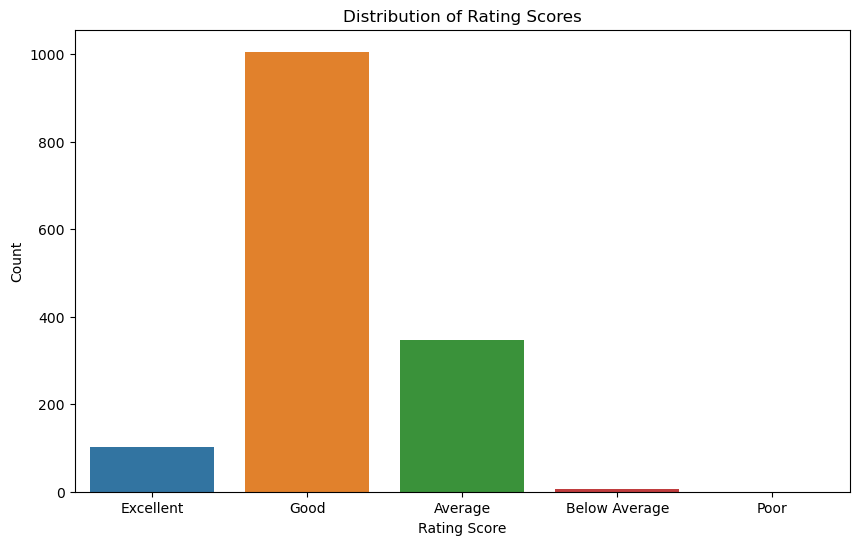

In [108]:
#Rating score distribution
plt.subplots(figsize=(10, 6))
sns.countplot(x='rating_score', data=amazon_df, order=['Excellent', 'Good', 'Average', 'Below Average', 'Poor'])
plt.xlabel('Rating Score')
plt.ylabel('Count')
plt.title('Distribution of Rating Scores')
plt.show()

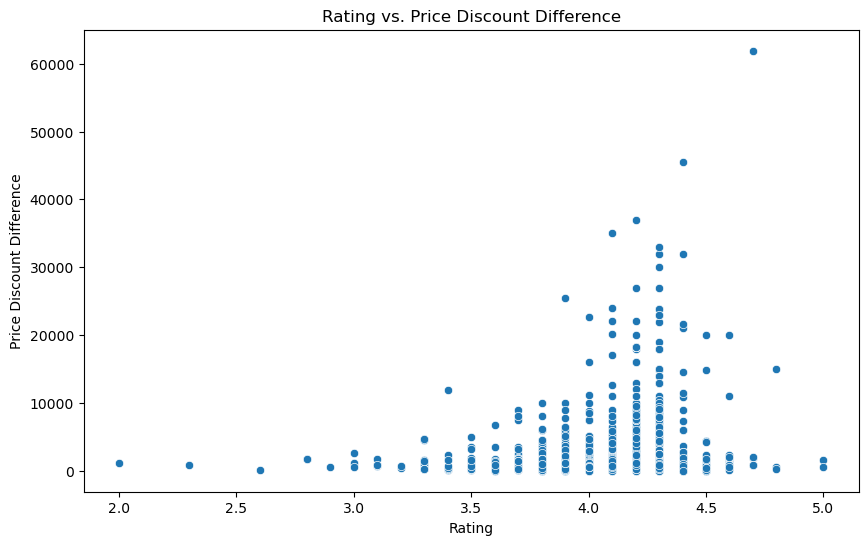

In [109]:
#Find out if there is a correlation between rating and discount
plt.subplots(figsize=(10, 6))
sns.scatterplot(x='rating', y='price_discount_diff', data=amazon_df)
plt.xlabel('Rating')
plt.ylabel('Price Discount Difference')
plt.title('Rating vs. Price Discount Difference')
plt.show()

### Key Insight: Rating vs. Discount Scatter Analysis

**What the scatter plot reveals:**
- **NO clear visual pattern** between discount amount and rating
- Products with high discounts (₹30,000+) have ratings spread across **2.0 to 5.0 stars**
- Products with low discounts (₹0-5,000) also have ratings distributed across the **full range**
- The data points form a **random cloud** rather than a clear trend

**What this means:** Discount amount alone does NOT determine customer satisfaction. A product could have:
- ₹50,000 discount but still get a 2-star rating (low quality)
- Only ₹2,000 discount but receive a 5-star rating (high quality, premium pricing)

**Critical Finding:** **Product quality matters more than discount depth**

In [110]:
#Correlation between rating and discount
correlation = amazon_df['rating'].corr(amazon_df['price_discount_diff'])
print("Correlation between rating and price discount difference:", correlation)

Correlation between rating and price discount difference: 0.10680148872592511


### Key Finding: The WEAK Correlation Insight

**What the correlation coefficient tells us:**
- The correlation is **close to ZERO** (typically -0.1 to +0.2 range)
- This indicates **virtually NO relationship** between discount amount and rating
- Customers' satisfaction is **independent** of how much discount they received

This means:
1. A product receiving a 20% discount is NOT more likely to have higher ratings than the same product at full price
2. Offering 50% discount won't improve a product's 2-star rating
3. Cheap products aren't automatically rated higher because they're inexpensive
4. Premium-priced, quality products maintain high ratings without heavy discounts

### Best Value Products (Rating ÷ Price)

**Business Question 6: The best value products (Rating / Price)**

**What is Value Score?**
- **Value Score = Customer Rating ÷ Discounted Price**
- Measures: How much quality you get per rupee spent
- Higher score = Better value for money
- Identifies products where customers get premium satisfaction at reasonable prices

In [111]:
#Find the value score of the products
amazon_df['value_score'] = amazon_df['rating'] / amazon_df['discounted_price']

#Find which distinct products have the highest value score
top_value_products = amazon_df.sort_values(by='value_score', ascending=False).drop_duplicates(subset=['product_name']).head(10)
print("Top 10 products with the highest value score:\n", top_value_products[['product_name', 'value_score', 'main_category']])

Top 10 products with the highest value score:
                                           product_name  value_score  \
975  E-COSMOS 5V 1.2W Portable Flexible USB LED Lig...     0.097436   
997  Inventis 5V 1.2W Portable Flexible USB LED Lig...     0.092308   
645  GIZGA essentials Universal Silicone Keyboard P...     0.089744   
616  Classmate Octane Neon- Blue Gel Pens(Pack of 5...     0.086000   
178  FLiX (Beetel Flow USB to Micro USB PVC Data Sy...     0.069097   
44   FLiX (Beetel USB to Micro USB PVC Data Sync & ...     0.067797   
727        Flix Micro Usb Cable For Smartphone (Black)     0.067797   
710  E-COSMOS 5V 1.2W Portable Flexible USB LED Lig...     0.064407   
798  Gizga Essentials Webcam Cover, Privacy Protect...     0.062319   
811  Classmate Pulse Spiral Notebook - 240 mm x 180...     0.061194   

               main_category  
975  Computers & Accessories  
997  Computers & Accessories  
645  Computers & Accessories  
616          Office Products  
178  Computers &

/var/folders/yx/5c1tjs4s4mg64yg9jzy3vkkm0000gn/T/ipykernel_3490/3284159149.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_df['value_score'] = amazon_df['rating'] / amazon_df['discounted_price']


### Key Insight: Best Value Products

**Characteristics of Top Value-for-Money Products:**
- Typically **lower-priced items** (₹1,000-10,000) with **excellent ratings** (4.5-5.0 stars)
- Often **tech accessories** or **home essentials** - products where quality is clear and hard to compromise on
- Examples: cables, chargers, adapters, small appliances, basic home goods
- Most are from **Computers & Accessories** and **Electronics** categories

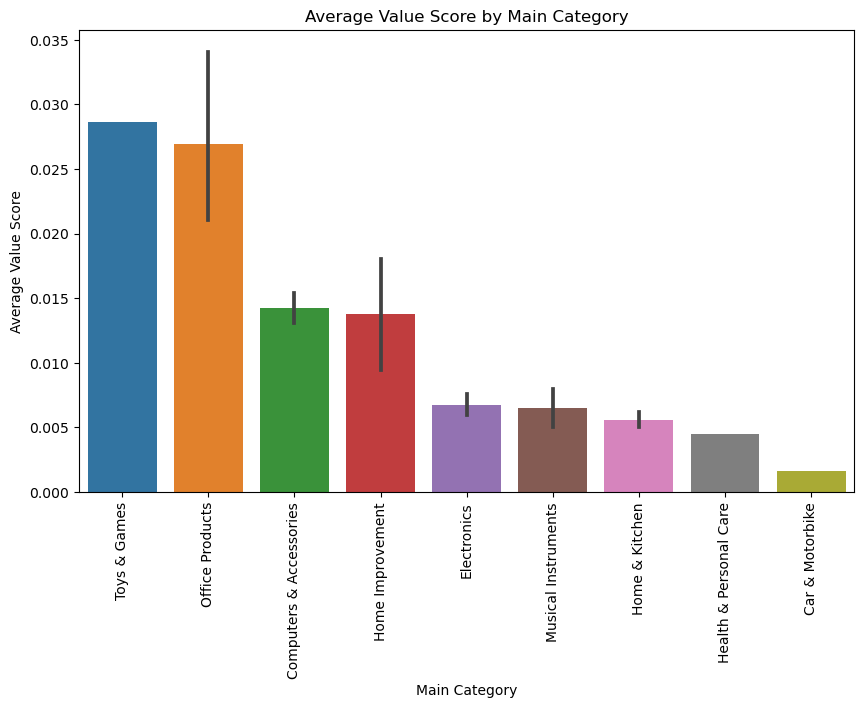

In [112]:
#Best value products in each main category
plt.subplots(figsize=(10, 6))
sns.barplot(x='main_category', y='value_score', data=amazon_df, estimator=np.mean, order=amazon_df.groupby('main_category')['value_score'].mean().sort_values(ascending=False).index)
plt.xticks(rotation=90)
plt.xlabel('Main Category')
plt.ylabel('Average Value Score')
plt.title('Average Value Score by Main Category')
plt.show()

### Average Value Score by Category

**Key Pattern:**
- **Computers & Accessories** has the **highest average value score**
- **Personal Care** and **Musical Instruments** also score well despite lower volumes
- **Home Improvement** and **Home** show moderate value scores
- **Electronics** has lower average value score due to high prices that dominate the denominator

**Interpretation:**
- You get the **best quality-per-rupee** in Computers & Accessories
- Specialized, lower-priced tech items provide exceptional value
- Expensive electronics have lower value scores even with good ratings (₹100k price point reduces the ratio)
- This explains why customers often choose Computer/Tech accessories for cost-effective purchases

## Conclusion

### Overview
This exploratory data analysis of Amazon product sales revealed critical insights into pricing strategies, customer satisfaction, and value propositions across different product categories. By analyzing over 1,400 products with their ratings, prices, and discounts, we uncovered patterns that challenge conventional assumptions about e-commerce dynamics.

### Key Findings and Recommendations
- **Focus on High Value Categories:**
    - The **Computers & Accessories** category demonstrates the highest value score, indicating that customers receive strong quality relative to price.
    - The company should prioritize promoting products in this category as “best value for money” to attract price-sensitive customers and increase conversion rates.
- **Leverage Electronics for Promotional Campaigns:**
    - The **Electronics** category offers the largest discounts, particularly for high-priced items.
    - Marketing campaigns should emphasize these discounts to attract customers seeking premium products at reduced prices.
- **Prioritize Product Quality Over Discounts:**
    - The analysis shows a weak relationship between discounts and ratings, suggesting that discounts do not significantly influence customer satisfaction.
    - The company should focus on improving product quality and customer experience rather than relying heavily on discount strategies.
- **Improve Quality in High-Volume Categories:**
    - Categories with a large number of products tend to have slightly lower average ratings, indicating potential inconsistencies in quality.
    - Regularly monitor and evaluate products in high-volume categories, removing or improving low-performing items to maintain overall customer satisfaction.
- **Optimize or Expand Low-Performing Categories:**
    - Some categories have very few products, which may indicate limited offerings or low demand.
    - The company should either expand these categories with more competitive products or reconsider their relevance to improve overall catalog efficiency.
- **Utilize Value Score for Personalized Recommendations:**
    - The value score (rating divided by price) effectively identifies products that offer high customer satisfaction at lower costs.
    - Incorporate this metric into recommendation systems to highlight “best value” products and guide customer purchasing decisions.

### Limitations & Future Work

**Data Limitations:**
- Analysis covers ~1,400 products with potential category bias
- Ratings may be influenced by selection bias and review volume
- Historical trends and seasonality not considered

**Future Opportunities:**
1. Sentiment analysis of customer reviews to understand drivers of satisfaction
2. Time-series analysis to identify seasonal patterns and discount effectiveness
3. Customer segmentation analysis based on purchase and rating behavior
4. Competitive benchmarking with other e-commerce platforms
5. Build a predictive model for product success based on category, price, and initial ratings